# 09 - Valuation calibration (archived pre-pivot diagnostic)

**Archive notice (2026-08-14): this notebook is not in the live dependency graph and must not be rerun as the Stage 1 to Stage 2 interface.** It uses the legacy notebook-08 factors, a failed dollar anchor, and the retired CMM route. The live interface is the non-monetary, explicitly assumption-dependent scenario system in `configs/cycles/s1-v2-20260814/pseudo_utility_scenarios.json`, `src/pseudo_utility.py`, and the cycle-scoped Gate 2 manifest. The historical cells and outputs below are retained only as diagnostic evidence for why a monetary interpretation was rejected.

Historically, this notebook attempted to turn Stage 1 latent **preference scores** (`s_{u,g} = P_u . Q_g`, notebook 08) into per-user **dollar valuations** for the cross-moment bundle-size pricing optimizer (notebook 06). Its intended bridge was a monotone affine link `v = a + b * s` whose scale was fixed by a censored-price anchor. That approach is superseded.

The central finding of this notebook is that **the standalone price cannot identify the dollar scale on this data**. Conditional on preference, more expensive games are owned *more*, not less (the quality and exposure confound), so the censoring logic breaks across games. This is reported, not patched.

The finding is not fatal, because the headline economics are **scale invariant**: with near-zero marginal cost for digital goods, scaling every valuation by a constant scales prices and revenues but leaves the bundle-size-pricing-vs-separate-selling and pure-bundling revenue *ratios*, and the correlation-sweep uplift, unchanged. So the multiplicative scale is set by a transparent normalization and swept, and only the location of the free-disposal floor and the cross-good correlation structure (both reported with sensitivity) affect the ratios. See notes/optimization_models.md and notes/assumptions_and_limitations.md.

In [1]:
import os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
sys.path.insert(0, '..')
from src import calibration as cal
from src import bundle_pricing as bp

warnings.filterwarnings('ignore', message='delta_grad == 0.0')
os.makedirs('../outputs/tables', exist_ok=True)
os.makedirs('../outputs/figures', exist_ok=True)

z = np.load('../outputs/tables/preference_factors.npz', allow_pickle=True)
P, Q = z['P'].astype(float), z['Q'].astype(float)
item_ids = z['item_ids'].astype(str)
idpos = {iid: i for i, iid in enumerate(item_ids)}
n_users = P.shape[0]

gf = pd.read_csv('../outputs/tables/game_features.csv')
gf['item_id'] = gf['item_id'].astype(str)
gf = gf.set_index('item_id')
own   = gf['ownership_count'].reindex(item_ids).to_numpy(float)
price = gf['standalone_price'].reindex(item_ids).to_numpy(float)
hasp  = gf['has_price'].reindex(item_ids).fillna(False).to_numpy(bool)
ptime = gf['playtime_mean'].reindex(item_ids).to_numpy(float)
rates = own / n_users
s_bar = cal.mean_scores(P, Q)                 # per-game mean preference score
priced = hasp & np.isfinite(price) & (own >= 1)
print(f'factors P {P.shape}, Q {Q.shape}; priced games used: {int(priced.sum())}')

# A concrete full-coverage demo bundle used throughout (EA Racing Pack, 5 games).
bi = pd.read_csv('../outputs/tables/bundle_items_df.csv',
                 dtype={'bundle_id': str, 'item_id': str}).dropna(subset=['item_id'])
DEMO = '1009'
demo_name = 'EA Racing Pack'
demo_items = bi[bi['bundle_id'] == DEMO]['item_id'].tolist()
demo_idx = [idpos[i] for i in demo_items if i in idpos]
demo_sizes = list(range(1, len(demo_idx) + 1))
print(f'demo bundle {DEMO} ({demo_name}): {len(demo_idx)} games mapped, sizes {demo_sizes}')

factors P (70912, 32), Q (10978, 32); priced games used: 8550
demo bundle 1009 (EA Racing Pack): 5 games mapped, sizes [1, 2, 3, 4, 5]


## Why the standalone price cannot anchor the dollar scale

The censoring logic is: if a fraction `r_g` of users own game g, the marginal owner values it at exactly `price_g`, so `price_g` should equal the `(1 - r_g)` quantile of that game's user-score distribution. We test this three ways, all of which require the price coefficient to have the value-consistent sign for a positive dollar scale to exist:

- **Aggregate link regression**: regress the link-transformed ownership rate on the per-game mean score and price; a valid scale needs the price coefficient negative.
- **Quantile anchor** (the cleanest test): regress `price_g` on the `(1 - r_g)` quantile of the user scores; a valid scale needs a positive slope.

In [2]:
# Aggregate link regression (probit and logit) and the quantile anchor.
agg_probit = cal.fit_calibration_aggregate(s_bar[priced], price[priced], rates[priced], n_users, 'probit')
agg_logit  = cal.fit_calibration_aggregate(s_bar[priced], price[priced], rates[priced], n_users, 'logit')

rng = np.random.default_rng(0)
usamp = rng.choice(n_users, size=20000, replace=False)
Psub = P[usamp]
idx = np.where(priced)[0]
qg = np.empty(idx.size)
for s0 in range(0, idx.size, 1000):           # chunk to bound memory
    cols = idx[s0:s0 + 1000]
    Sb = Psub @ Q[cols].T
    qg[s0:s0 + cols.size] = cal.censoring_quantiles(Sb, rates[cols])
quant = cal.fit_calibration_quantile(qg, price[idx])

print('price anchors (all should be INVALID -> the finding):')
print(f"  aggregate probit: valid={agg_probit.valid}  price-coef t={agg_probit.diagnostics['t_gamma_p']:+.1f}  R2={agg_probit.diagnostics['r2']:.3f}")
print(f"  aggregate logit : valid={agg_logit.valid}  price-coef t={agg_logit.diagnostics['t_gamma_p']:+.1f}")
print(f"  quantile anchor : valid={quant.valid}  slope b={quant.diagnostics['b']:+.2f}  "
      f"Spearman(price, q)={quant.diagnostics['spearman_price_quantile']:+.3f}  R2={quant.diagnostics['r2']:.3f}")

price anchors (all should be INVALID -> the finding):
  aggregate probit: valid=False  price-coef t=+6.4  R2=0.347
  aggregate logit : valid=False  price-coef t=+5.6
  quantile anchor : valid=False  slope b=-20.46  Spearman(price, q)=-0.243  R2=0.022


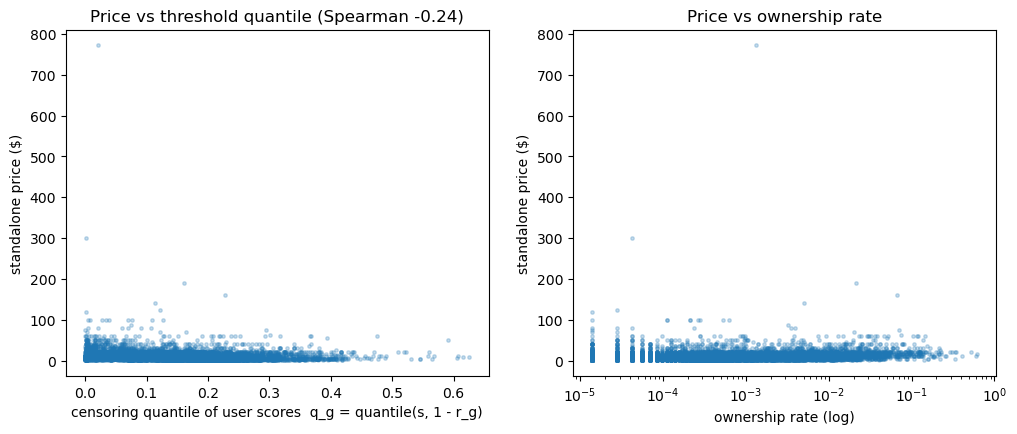

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].scatter(qg, price[idx], s=6, alpha=0.25)
ax[0].set_xlabel('censoring quantile of user scores  q_g = quantile(s, 1 - r_g)')
ax[0].set_ylabel('standalone price ($)')
ax[0].set_title(f'Price vs threshold quantile (Spearman {quant.diagnostics["spearman_price_quantile"]:+.2f})')
ax[1].scatter(rates[idx], price[idx], s=6, alpha=0.25)
ax[1].set_xscale('log')
ax[1].set_xlabel('ownership rate (log)')
ax[1].set_ylabel('standalone price ($)')
ax[1].set_title('Price vs ownership rate')
plt.savefig('../outputs/figures/09_price_anchor.png')
plt.show()

## Scale invariance: the headline results do not need the dollar scale

Before choosing any scale, we confirm the property that makes the finding non-fatal. Scaling every valuation by a constant should leave the profit *ratios* unchanged when marginal cost is zero. The benchmark definitions match notebook 06: **separate selling** is the sum of independently optimized single-item profits, **pure bundling** is the best single price for the grand bundle, and **bundle-size pricing (BSP)** is the cross-moment menu, reported as the better of the CMM menu and the pure-bundle policy so it weakly dominates pure bundling.

In [4]:
def separate_selling_profit(V, c=0.0):
    """Sum over items of the independently optimized single-item profit."""
    N = V.shape[0]
    total = 0.0
    for j in range(V.shape[1]):
        v = np.sort(V[:, j])[::-1]
        profit = (v - c) * (np.arange(1, v.size + 1) / N)
        total += max(0.0, profit.max())
    return total

def pure_bundling_profit(V, c=0.0):
    """Best single price for the grand bundle (size n)."""
    N = V.shape[0]
    w = np.sort(V.sum(axis=1))[::-1]
    profit = (w - c) * (np.arange(1, w.size + 1) / N)
    return max(0.0, profit.max())

def bsp_profit(omega, Sigma, V, sizes, c=0.0):
    """Realised profit of the CMM-optimal menu, floored at the pure-bundle policy."""
    conv = bp.optimize_convex(omega, Sigma, c, sizes)
    cmm_realised = bp.evaluate_schedule(V, conv['prices'], sizes, c)
    return max(cmm_realised, pure_bundling_profit(V, c)), conv

# Use a temporary normalization just to produce a valuation matrix for the check.
_cal0 = cal.normalize_calibration(s_bar[priced], price[priced])
print('scale invariance on the demo bundle (ratios must be identical):')
for lam in [1.0, 10.0, 100.0]:
    cl = cal.CalibrationResult(_cal0.a * lam, _cal0.b * lam, _cal0.sigma, 'probit', True, {})
    om, Sg, V, _ = cal.valuation_moments(P, Q, demo_idx, demo_sizes, cl, 'ledoit_wolf')
    b, _ = bsp_profit(om, Sg, V, demo_sizes)
    sep = separate_selling_profit(V); pure = pure_bundling_profit(V)
    print(f'  lambda={lam:6.1f}   BSP/separate={b/sep:.4f}   pure/separate={pure/sep:.4f}')

scale invariance on the demo bundle (ratios must be identical):
  lambda=   1.0   BSP/separate=0.7698   pure/separate=0.7698
  lambda=  10.0   BSP/separate=0.7698   pure/separate=0.7698
  lambda= 100.0   BSP/separate=0.7698   pure/separate=0.7698


## A transparent normalization for the scale

Since price cannot set the scale, we fix it by an explicit normalization: the multiplicative scale `b` so the spread of per-game (mean-score) valuations matches the spread of prices, and the location `a` so their medians match. This is a stated assumption, not an identification, and both knobs are swept later. The free-disposal floor `v = max(a + b s, 0)` then determines how many user-game valuations are zero.

normalization: a = 7.598,  b = 620.995,  implied noise sigma = 13.271
diagnostics: scale assumed, not identified from price; swept in sensitivity
fraction of (user, game) valuations floored to 0: 0.059


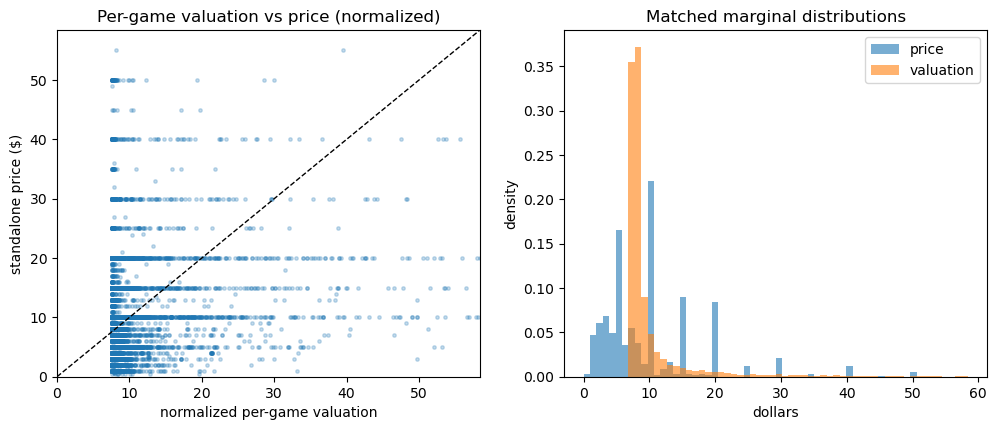

In [5]:
calib = cal.normalize_calibration(s_bar[priced], price[priced])
print(f'normalization: a = {calib.a:.3f},  b = {calib.b:.3f},  implied noise sigma = {calib.sigma:.3f}')
print(f"diagnostics: {calib.diagnostics['note']}")

Sflo = Psub @ Q[:2000].T
frac_floor = float((calib.a + calib.b * Sflo < 0).mean())
print(f'fraction of (user, game) valuations floored to 0: {frac_floor:.3f}')

implied = calib.a + calib.b * s_bar[priced]   # per-game mean valuation (pre-floor)
lim = float(np.nanpercentile(np.concatenate([implied, price[priced]]), 99))
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].scatter(implied, price[priced], s=6, alpha=0.25)
ax[0].plot([0, lim], [0, lim], 'k--', lw=1)
ax[0].set_xlim(0, lim); ax[0].set_ylim(0, lim)
ax[0].set_xlabel('normalized per-game valuation')
ax[0].set_ylabel('standalone price ($)')
ax[0].set_title('Per-game valuation vs price (normalized)')

ax[1].hist(price[priced], bins=60, range=(0, lim), alpha=0.6, label='price', density=True)
ax[1].hist(implied, bins=60, range=(0, lim), alpha=0.6, label='valuation', density=True)
ax[1].set_xlabel('dollars')
ax[1].set_ylabel('density')
ax[1].legend()
ax[1].set_title('Matched marginal distributions')
plt.savefig('../outputs/figures/09_normalization.png')
plt.show()

## Face validity of the relative valuations

The scale is assumed, so what must hold up is the *relative* structure. Two checks. The per-game mean valuation is, by construction, almost a monotone function of ownership (the preference model is fit on ownership), so its agreement with ownership is mechanical and internal, not evidence. The one semi-independent signal is **playtime**: higher-valued games should be played more. We report the (weak, noisy) playtime association honestly, and show the demo bundle's per-item valuations against ownership and playtime.

In [6]:
vbar = np.empty(Q.shape[0])
for s0 in range(0, Q.shape[0], 2000):
    Sb = Psub @ Q[s0:s0 + 2000].T
    vbar[s0:s0 + Sb.shape[1]] = np.maximum(calib.a + calib.b * Sb, 0.0).mean(axis=0)

fv = np.isfinite(ptime) & (own >= 5)
print('face validity of per-game mean calibrated valuation:')
print(f'  Spearman(valuation, ownership) = {spearmanr(vbar, own).statistic:+.3f}   (mechanical / internal)')
print(f'  Spearman(valuation, playtime)  = {spearmanr(vbar[fv], ptime[fv]).statistic:+.3f}   (independent, n={int(fv.sum())})')
print('  note: playtime is a noisy value signal (36% of ownership rows have zero playtime).')

demo_tab = pd.DataFrame({
    'item_id': [item_ids[i] for i in demo_idx],
    'mean_valuation': np.round(vbar[demo_idx], 2),
    'ownership': own[demo_idx].astype(int),
    'playtime_mean': np.round(ptime[demo_idx], 1),
    'price': price[demo_idx],
})
print('')
print('demo bundle per-item face validity:')
print(demo_tab.to_string(index=False))

face validity of per-game mean calibrated valuation:
  Spearman(valuation, ownership) = +0.996   (mechanical / internal)
  Spearman(valuation, playtime)  = +0.168   (independent, n=9192)
  note: playtime is a noisy value signal (36% of ownership rows have zero playtime).

demo bundle per-item face validity:
item_id  mean_valuation  ownership  playtime_mean  price
  17430           17.23       1062          486.7   9.99
  24740           71.54       7064          299.2  19.99
  24870           12.53        523          379.4  19.99
  47870           28.83       2367          505.7  19.99
  47920           11.43        402          474.8  19.99


## The moment bridge and its conditioning

The Stage 2 to Stage 3 interface: calibrated per-user valuations to the cross-moment inputs `(omega, Sigma)` for an item set, via the existing bridge in `src/bundle_pricing.py`. Successive size-wise partial sums are mechanically near-collinear, so the raw covariance is ill-conditioned; Ledoit-Wolf shrinkage restores a positive-definite `Sigma`. We report the conditioning before and after.

In [7]:
omega, Sigma, V, info = cal.valuation_moments(P, Q, demo_idx, demo_sizes, calib, 'ledoit_wolf')
print(f'item set: demo bundle {DEMO}, sizes {demo_sizes}')
print(f'omega (mean top-s valuation): {np.round(omega, 2)}')
print(f'Sigma diagonal (variances):   {np.round(np.diag(Sigma), 1)}')
print(f"Sigma condition number: before={info['cov']['cond_before']:.2e}  after Ledoit-Wolf={info['cov']['cond_after']:.2e}")
print(f'Sigma minimum eigenvalue (must be > 0): {np.linalg.eigvalsh(Sigma)[0]:.4e}')
print(f'valuation matrix V: {V.shape}, all non-negative: {bool(np.all(V >= 0))}')

item set: demo bundle 1009, sizes [1, 2, 3, 4, 5]
omega (mean top-s valuation): [ 80.7  105.94 121.73 133.61 141.43]
Sigma diagonal (variances):   [22772.2 31014.  36141.6 40157.4 43664.6]
Sigma condition number: before=8.52e+04  after Ledoit-Wolf=2.01e+04
Sigma minimum eigenvalue (must be > 0): 8.5546e+00
valuation matrix V: (70912, 5), all non-negative: True


## Location sensitivity (the discipline carried into Stage 3 and 4)

The location `a`, through the free-disposal floor, does affect the ratios. We sweep it (in dollars, via `a_shift`) and report the resulting floor fraction and the BSP-vs-separate uplift on the demo bundle. For this bundle the uplift stays below one across the whole sweep: the five racing games are positively correlated in value, the textbook case where bundling does not help, and that qualitative conclusion is robust to the calibration location. The full cross-bundle economics and the correlation sweep are Stage 4.

 a_shift    a  floor_frac  BSP_over_separate
     -10 -2.4       0.702             0.9159
      -5  2.6       0.145             0.8808
       0  7.6       0.059             0.7698
       5 12.6       0.032             0.6788
      10 17.6       0.020             0.7853


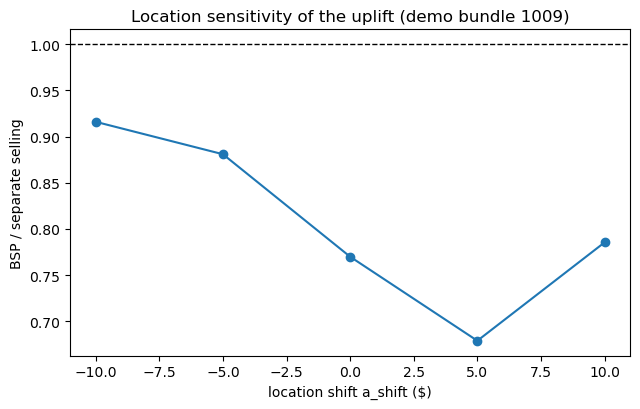

In [8]:
shifts = [-10, -5, 0, 5, 10]
rows = []
for ash in shifts:
    cl = cal.normalize_calibration(s_bar[priced], price[priced], a_shift=ash)
    om, Sg, Vv, _ = cal.valuation_moments(P, Q, demo_idx, demo_sizes, cl, 'ledoit_wolf')
    Sfl = Psub @ Q[:2000].T
    floor = float((cl.a + cl.b * Sfl < 0).mean())
    b, _ = bsp_profit(om, Sg, Vv, demo_sizes)
    sep = separate_selling_profit(Vv)
    rows.append({'a_shift': ash, 'a': round(cl.a, 2), 'floor_frac': round(floor, 3),
                 'BSP_over_separate': round(b / sep, 4)})
sweep = pd.DataFrame(rows)
print(sweep.to_string(index=False))

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(sweep['a_shift'], sweep['BSP_over_separate'], 'o-')
ax.axhline(1.0, color='k', ls='--', lw=1)
ax.set_xlabel('location shift a_shift ($)'); ax.set_ylabel('BSP / separate selling')
ax.set_title(f'Location sensitivity of the uplift (demo bundle {DEMO})')
plt.tight_layout(); plt.savefig('../outputs/figures/09_location_sweep.png'); plt.show()

## Save the calibration artifact

We persist the chosen normalization and the failed-anchor diagnostics so Stage 3 (bundle-size pricing on real item sets) can rebuild per-user valuations from the factors without re-fitting. The dollar scale is an assumption recorded here, to be swept downstream.

In [9]:
artifact = pd.DataFrame([{
    'method': calib.diagnostics['method'],
    'a': calib.a, 'b': calib.b, 'sigma': calib.sigma, 'link': calib.link,
    'b_scale': calib.diagnostics['b_scale'], 'a_shift': calib.diagnostics['a_shift'],
    'n_priced_games': int(priced.sum()),
    'frac_floored': frac_floor,
    'anchor_probit_valid': agg_probit.valid,
    'anchor_probit_price_t': agg_probit.diagnostics['t_gamma_p'],
    'anchor_quantile_valid': quant.valid,
    'anchor_quantile_slope_b': quant.diagnostics['b'],
    'anchor_quantile_spearman': quant.diagnostics['spearman_price_quantile'],
}])
artifact.to_csv('../outputs/tables/valuation_calibration.csv', index=False)
print('saved ../outputs/tables/valuation_calibration.csv')
print(artifact.T.to_string(header=False))

saved ../outputs/tables/valuation_calibration.csv
method                    normalization
a                              7.597817
b                             620.99497
sigma                         13.270726
link                             probit
b_scale                             1.0
a_shift                             0.0
n_priced_games                     8550
frac_floored                   0.058706
anchor_probit_valid               False
anchor_probit_price_t          6.371268
anchor_quantile_valid             False
anchor_quantile_slope_b      -20.461011
anchor_quantile_spearman       -0.24268


## Notes

- The standalone price does not identify a dollar valuation scale here: conditional on preference, ownership rises with price (quality and exposure confound), so the censoring anchor fails. This is a finding, consistent with the endogeneity caveat in notes/assumptions_and_limitations.md.
- The dollar scale is therefore set by an explicit normalization and treated as an assumption. Because the profit ratios are scale invariant (zero marginal cost), the bundle-size-pricing-vs-separate-selling and pure-bundling comparisons and the correlation sweep do not depend on it. Absolute dollar prices and any comparison to the observed Steam bundle price are reported only under the swept scale, as a sensitivity, not a claim.
- The location of the free-disposal floor does affect the ratios and is swept (the location sensitivity table); the cross-good correlation structure, which drives the bundling economics, comes from the latent factors and is preserved by the affine map.
- These remain preference-derived valuations on a normalized scale, not measured willingness to pay. Panel and proxy caveats from the data stage (Australian panel, ownership not purchase, snapshot prices) still hold.